# Cargar datos y generar los conjuntos de entrenamiento y test

In [144]:
import pandas as pd

# file_path = 'data_set_limpio.pkl'
file_path = 'datasets_pkl/data_set_limpio_sin_not_for_sale_post_kmeans_nat_div_club.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print(df.columns)
df.sample(n=5)


Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado', 'Nat_cluster',
       'Division_cluster', 'Club_cluster'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,Age,Wage,AT Apps,AT Gls,Team,Caps,Yth Apps,Style,Rc Injury,Best Role,Best Duty,Best Pos,Acc,Aer,Agg,Agi,Ant,Bal,Bra,Cmd,Com,Cmp,Cnt,Cor,Cro,Dec,Det,Dri,Ecc,Fin,Fir,Fla,Fre,Han,Hea,Jum,Kic,Ldr,Lon,L Th,Mar,Nat .1,OtB,1v1,Pac,Pas,Pen,Pos,Pun,Ref,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado,Nat_cluster,Division_cluster,Club_cluster
92093,ITA,Italian Serie D Grp. E,Trestina,Italy (Serie D Grp. E),Left Only,Weak,Very Strong,D (C),190,83,30,1900,303,11,-,0,0,Physical,-,No-Nonsense Centre-Back,Stopper,D (C),8,2,13,8,10,12,12,2,1,10,11,4,5,10,12,4,3,6,6,5,4,2,12,13,3,13,8,9,11,11,7,1,9,8,8,11,3,2,2,11,12,12,9,7,1,7,10,35000,1,4,0
46259,GER,3. Liga,SpVgg Bayreuth,Germany (3. Liga),Right,Very Strong,Reasonable,"D (C), DM, M (C)",184,75,19,2300,27,5,-,0,0,Leader,-,Defensive Midfielder,Defend,DM,12,3,14,10,11,9,8,3,3,7,7,3,6,14,10,6,2,6,11,5,6,2,9,10,4,12,7,1,10,13,4,2,13,12,4,14,2,2,1,8,8,12,9,10,2,9,13,66000,1,0,0
61596,SUI,German Div. Westphalia,SC Paderborn II,Germany (Westphalia),Right,Very Strong,Reasonable,D (RC),184,74,18,975,2,0,-,0,0,Intelligent,-,Full-Back,Defend,D (R),5,2,7,9,8,8,9,1,2,8,9,7,6,15,6,3,2,1,9,5,4,1,9,9,3,7,1,3,9,12,7,4,8,9,2,10,3,2,3,4,5,14,7,7,2,5,8,23500,1,0,2
102253,UKR,Ukrainian First League,Prykarpattia,Ukraine (First League),Left Only,Weak,Very Strong,D (L),174,68,19,500,0,0,-,0,0,Physical,-,No-Nonsense Full-Back,Defend,D (L),14,2,13,13,7,6,6,2,1,2,5,3,2,14,10,5,2,2,9,5,1,1,6,7,3,1,1,5,4,9,5,3,11,2,3,7,2,2,3,5,5,10,6,4,2,5,6,2250,1,0,2
93318,ITA,Italian Serie A,Torino,Italy (Serie A),Right Only,Very Strong,Weak,D (C),191,78,18,1100,0,0,-,0,0,Physical,-,Central Defender,Defend,D (C),5,2,15,9,8,6,8,2,2,4,6,1,1,13,4,5,2,1,6,5,1,2,13,10,2,8,4,1,13,16,4,3,10,6,1,9,2,2,1,8,7,13,5,3,1,1,6,22500,1,0,0


In [147]:
import pandas as pd
visualizar_todo=False
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)


## Onehot para los clusters

In [145]:
categorical_cols=["Nat_cluster","Division_cluster","Club_cluster"]
df = pd.get_dummies(df, columns=categorical_cols)
df = df.astype({col: 'int' for col in df.select_dtypes('bool').columns})

## Dataframe solo con features numericas

In [148]:
import numpy as np
# Create new dataframe with only numeric columns
only_numeric_df = df.select_dtypes(include=[np.number])
print(only_numeric_df.columns)
# # Optional: Create a separate dataframe for non-numeric columns
# only_categoric_df = df.select_dtypes(exclude=[np.number])


Index(['Height', 'Weight', 'Age', 'Wage', 'AT Apps', 'AT Gls', 'Caps',
       'Yth Apps', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal', 'Bra', 'Cmd',
       'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri', 'Ecc', 'Fin',
       'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr', 'Lon', 'L Th',
       'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen', 'Pos', 'Pun', 'Ref',
       'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr', 'Vis', 'Wor',
       'transfer_value_estimado', 'Nat_cluster_0', 'Nat_cluster_1',
       'Nat_cluster_2', 'Nat_cluster_3', 'Nat_cluster_4', 'Nat_cluster_5',
       'Division_cluster_0', 'Division_cluster_1', 'Division_cluster_2',
       'Division_cluster_3', 'Division_cluster_4', 'Division_cluster_5',
       'Club_cluster_0', 'Club_cluster_1', 'Club_cluster_2', 'Club_cluster_3'],
      dtype='object')


## Generar conjuntos de entrenamiento y test

In [149]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
def train_test_sets(df):
    # To get the data as a new DataFrame
    X = df.loc[:, df.columns != 'transfer_value_estimado']
    y= df.loc[:, df.columns == 'transfer_value_estimado']
    rs=18
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rs)

    cat_columns = X_train.select_dtypes(exclude=['number']).columns

    # 2. Convert them to the 'category' dtype for both train and test
    for col in cat_columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)
    return X,y,X_train,X_test,y_train,y_test,cat_columns


In [150]:
X,y,X_train,X_test,y_train,y_test,cat_columns=train_test_sets(only_numeric_df)

# LinearRegression

Entrenamiento y evaluación

r2 train:  0.4756471830560125
coeficientes de la regresión  [[ 8.32590318e+03 -2.42065771e+03 -2.75205953e+04  8.29568529e+01
  -2.34817823e+03 -1.56227278e+03 -2.59635285e+04  3.86748538e+03
   1.26800970e+04  8.41455596e+03  7.40114457e+03  1.40066749e+04
   1.81213617e+04 -1.35743206e+04  1.53116917e+04  8.11984694e+03
   9.55796131e+02  2.15763099e+04  1.89814483e+04 -1.05448192e+04
   1.66466746e+03  2.71225384e+04  8.18548952e+03  1.27369804e+04
   1.58452200e+04  5.00263052e+03  3.19894850e+03  2.88507550e+04
   9.14963126e+03  1.93586126e+04 -2.07558142e+03 -6.06730500e+03
   6.23947289e+02  4.57000507e+03 -1.29669431e+04 -1.41795620e+04
   3.31724307e+03  1.48997261e+04  4.68640296e+03 -5.48278455e+03
   1.04579450e+04  5.90431577e+03  6.65039824e+03  7.75079517e+03
  -4.51894109e+03 -4.33426365e+03 -8.26253821e+03  1.65313823e+04
   1.64042372e+04  1.04292051e+04 -9.04968702e+03 -4.50836341e+03
   5.51362803e+03  1.83830877e+04  1.05532190e+04 -4.93783541e+04
  -7.06045625e+0

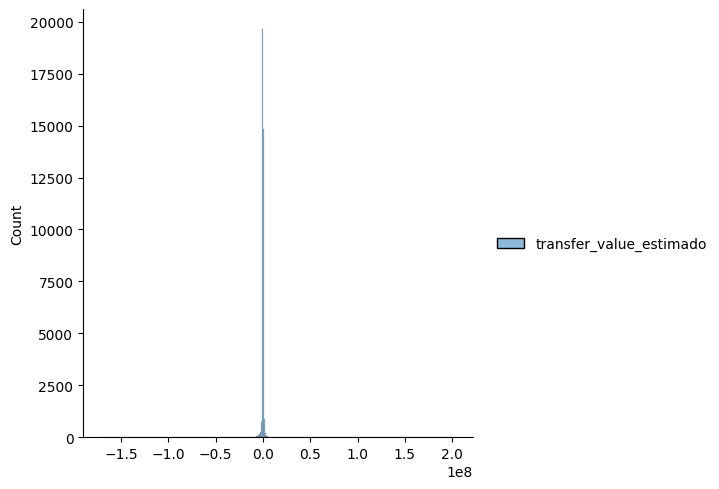

In [151]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

r2_score_train=reg.score(X_train, y_train)
print("r2 train: ",r2_score_train)
print("coeficientes de la regresión ",reg.coef_)
print("intercepto de la regresión ",reg.intercept_)

import seaborn as sns
y_pred=reg.predict(X_test)
r2_score_test=reg.score(X_test, y_test)
print("r2 test: ",r2_score_test)
residual = y_test - y_pred
sns.displot(residual)

# Ridge

In [152]:
from sklearn.linear_model import ridge_regression


# Lasso

# ElasticNet